In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("1. Lendo o arquivo CSV...")
df = pd.read_csv('creditcard.csv')

# Trata nomes de colunas (converte 'class' ou 'Class' para 'Class')
df.columns = [c.capitalize() if c.lower() == 'class' else c for c in df.columns]

# Remove linhas com valores nulos (NaN) para evitar erros
df = df.dropna()

print(f"Dataset pronto! Total de registros válidos: {df.shape[0]}")
print("\n--- Proporção das Classes ---")
print(df['Class'].value_counts(normalize=True) * 100)

print("\n2. Divisão e Padronização dos Dados...")
X = df.drop(columns=['Class'])
y = df['Class']

# Divisão mantendo a proporção exata de fraudes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Padronização das colunas Time e Amount
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("\n3. Treinando a Regressão Logística (Baseline)...")
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("\n=== Relatório de Classificação: Regressão Logística ===")
print(classification_report(y_test, y_pred_lr, target_names=['Legítima (0)', 'Fraude (1)']))

print("\n4. Treinando Random Forest...")
rf_model = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n=== Relatório de Classificação: Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Legítima (0)', 'Fraude (1)']))

print("\n Pipeline executado com sucesso!")

1. Lendo o arquivo CSV...
Dataset pronto! Total de registros válidos: 55550

--- Proporção das Classes ---
Class
0.0    99.719172
1.0     0.280828
Name: proportion, dtype: float64

2. Divisão e Padronização dos Dados...

3. Treinando a Regressão Logística (Baseline)...

=== Relatório de Classificação: Regressão Logística ===
              precision    recall  f1-score   support

Legítima (0)       1.00      0.98      0.99     11079
  Fraude (1)       0.15      0.97      0.26        31

    accuracy                           0.98     11110
   macro avg       0.57      0.98      0.62     11110
weighted avg       1.00      0.98      0.99     11110


4. Treinando Random Forest...

=== Relatório de Classificação: Random Forest ===
              precision    recall  f1-score   support

Legítima (0)       1.00      1.00      1.00     11079
  Fraude (1)       0.87      0.87      0.87        31

    accuracy                           1.00     11110
   macro avg       0.94      0.94      0.94   

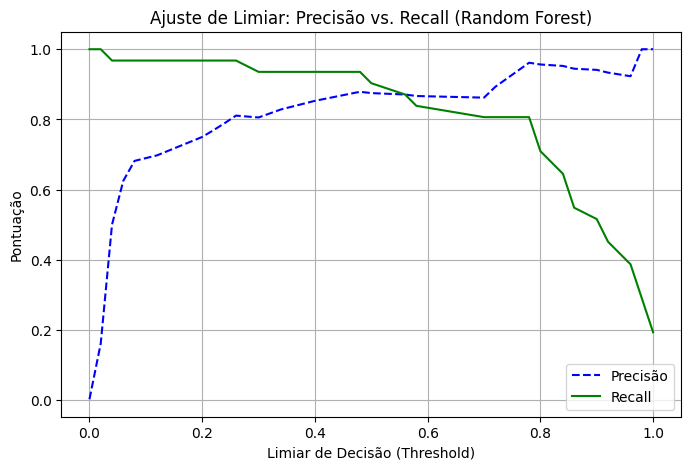


=== Avaliação com Limiar Customizado (0.35) ===
              precision    recall  f1-score   support

Legítima (0)       1.00      1.00      1.00     11079
  Fraude (1)       0.85      0.94      0.89        31

    accuracy                           1.00     11110
   macro avg       0.93      0.97      0.95     11110
weighted avg       1.00      1.00      1.00     11110



In [4]:
from sklearn.metrics import precision_recall_curve

# Probabilidades da classe de fraude (1) no Random Forest
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculando a curva
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_rf)

# Gráfico Precision-Recall
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precisão")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Limiar de Decisão (Threshold)")
plt.ylabel("Pontuação")
plt.title("Ajuste de Limiar: Precisão vs. Recall (Random Forest)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# Testando um limiar ajustado (ex: 0.35 para capturar mais fraudes)
custom_threshold = 0.35
y_pred_custom = (y_probs_rf >= custom_threshold).astype(int)

print(f"\n=== Avaliação com Limiar Customizado ({custom_threshold}) ===")
print(classification_report(y_test, y_pred_custom, target_names=['Legítima (0)', 'Fraude (1)']))

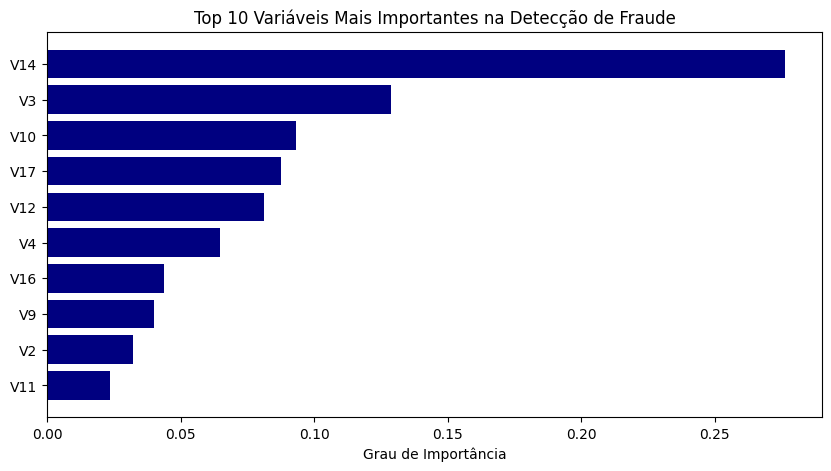

<Figure size 640x480 with 0 Axes>

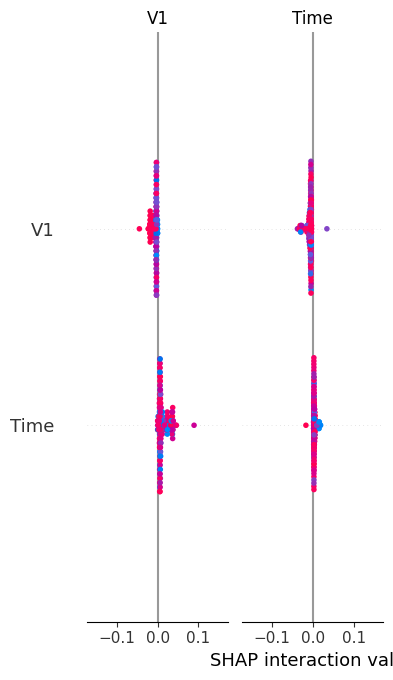

In [5]:
# 1. Feature Importance do Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Variável': feature_names, 'Importância': importances})
feature_df = feature_df.sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feature_df['Variável'].head(10)[::-1], feature_df['Importância'].head(10)[::-1], color='navy')
plt.xlabel('Grau de Importância')
plt.title('Top 10 Variáveis Mais Importantes na Detecção de Fraude')
plt.show()

# 2. Explicabilidade com SHAP
!pip install -q shap
import shap

explainer = shap.TreeExplainer(rf_model)
X_sample = X_test.sample(min(200, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

plt.figure()
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values, X_sample)